# Student Success Analytics

## Life Cycle of Machine Learning 
   
   1. Understanding problem statement
   2. Data Collection 
   3. Data checks to perform 
   4. Exploratory Data Analysis(EDA)
   5. Data pre-processing 
   6. Feature Engineering 
   7. Model training

Finally pushing the model to a server - cloud server

### 1. Problem Statement
This project understand how the student's performance(math score) is affected by other variables
like Gender, Ethnicity, Lunch, Level of education, etc.

### 2. Data Collection

• Dataset Source: From kaggle. Just search `student performance indicator dataset`.

• The dataset concists of 8 columns and 1000 records(rows).

#### 2.1 Importing dataset and required libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
%matplotlib inline 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [4]:
df.shape

(1000, 8)

#### 2.2 Dataset information

  • gender: sex of students -> (male or female)
  
  • race_ethnicity: ethnicity of students -> (group A, group B, group C, etc)

  • parental_level_of_education -> students' parent final education (bachelor's degree, some degree, master's degree, etc)

  • lunch -> having lunch before test (standard, free/reduced)

  • test_preparation_course -> complete or not complete before test

  • math_score: students' math score

  • reading_score: students' reading score
  
  • writing_score: students' writing score

### 3. Data checks to perform
 
  • Check missing dalues

  • Check duplicates

  • Check data types

  • Check the number of unique values of each column

  • Check Statitics of dataset
  
  • Check various categories present in the different categorical column

#### 3.1 Check missing values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

`Insight`: There are no missing values present in the dataset.

#### 3.2 Check duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

`Insight`: There are no duplicates in the dataset.

#### 3.3 Check data types 

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


`Insights:`We have 3 numerical features of types int and 5 categorical features of types str. We'll encode the
           categorical features' entries into number in the `Feature Engineering` part.

#### 3.4 Check the number of unique values in each column

In [ ]:
df.unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

### 3.5 Check Statistics of dataset

In [13]:
# For numerical features
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


`Insights`: We can see that in each numerical features, the `mean` is approximatively equal to the 
            `median(50%)` which means that the data of these features are `normally distributed`.
            Therefore no such a big problem of `skewed data`. However we may have outliers but we'll
            not remove them as there are real not values that differ from others.
            Below tests are for more confirmation.

[]

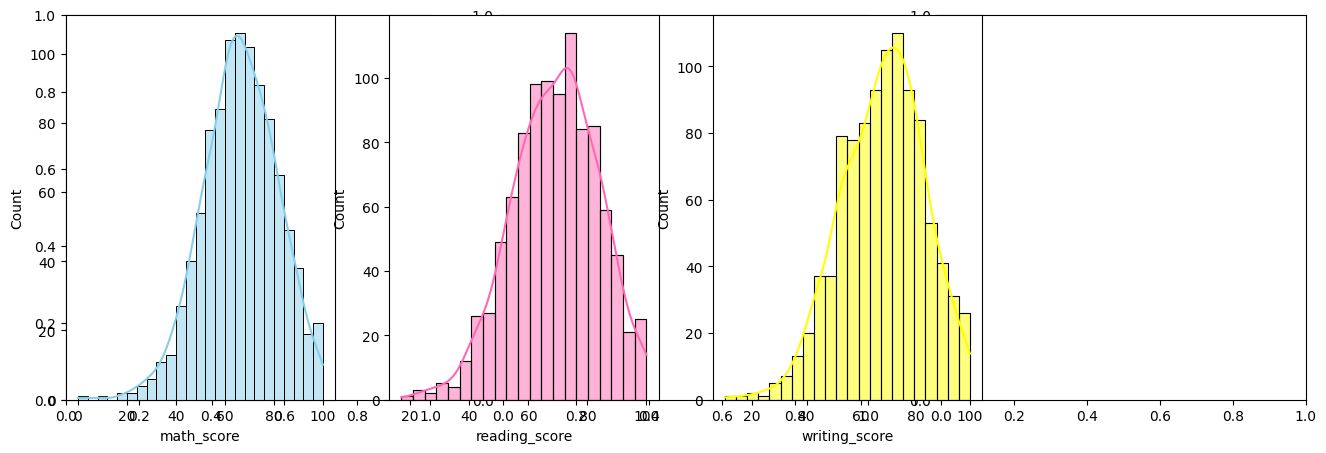

In [51]:
fig, axis = plt.subplots(1, 3, figsize=(16, 5))
plt.subplot(141)
sns.histplot(data=df, x='math_score', color='skyblue', kde=True)
plt.subplot(142)
sns.histplot(data=df, x='reading_score', color='hotpink', kde=True)
plt.subplot(143)
sns.histplot(data=df, x='writing_score', color='yellow', kde=True)
plt.plot()

[]

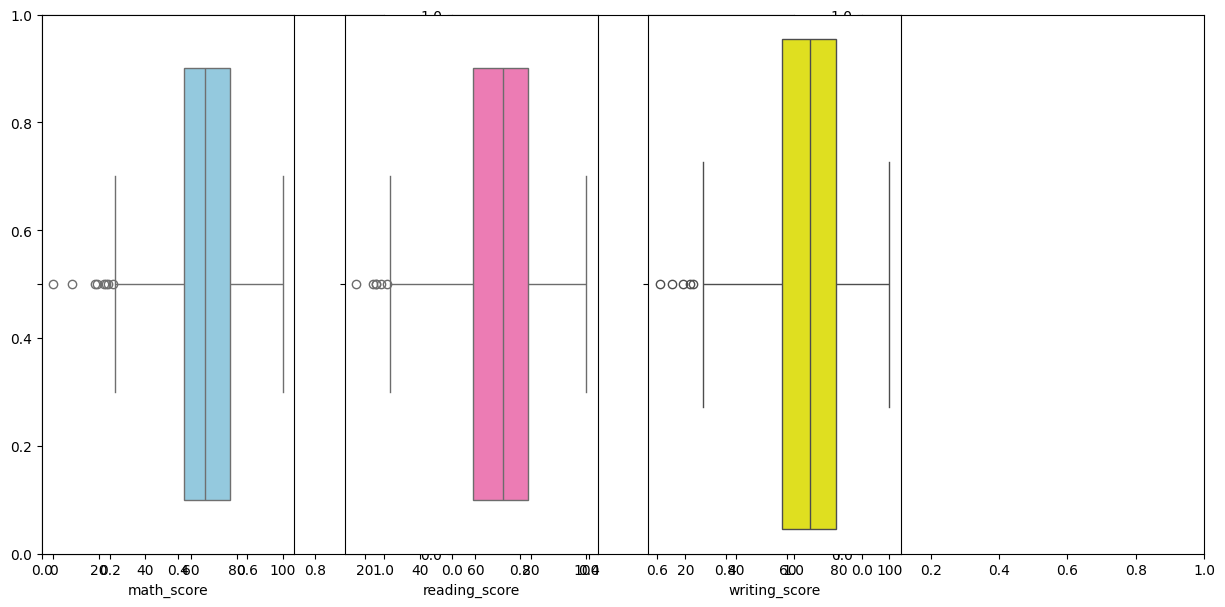

In [48]:
fig, axis = plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(141)
sns.boxplot(data=df, x='math_score', color='skyblue')
plt.subplot(142)
sns.boxplot(data=df, x='reading_score', color='hotpink')
plt.subplot(143)
sns.boxplot(data=df, x='writing_score', color='yellow')
plt.plot()

#### 3.6 Check various categories present in the different categorical features

In [36]:
print("Categories in 'gender': {}".format(df['gender'].unique()))
print('\n')
print("Categories in 'race_ethnicity': {}".format(df['race_ethnicity'].unique()))
print('\n')
print("Categories in 'parental_level_of_education': {}".format(df['parental_level_of_education'].unique()))
print('\n')
print("Categories in 'lunch': {}".format(df['lunch'].unique()))
print('\n')
print("Categories in 'test_preparation_course': {}".format(df['test_preparation_course'].unique()))

Categories in 'gender': <StringArray>
['female', 'male']
Length: 2, dtype: str


Categories in 'race_ethnicity': <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str


Categories in 'parental_level_of_education': <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str


Categories in 'lunch': <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str


Categories in 'test_preparation_course': <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [41]:
# Define numerical & categorical features
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'str']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print('We have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('We have {} categorical features: {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 4. Exploratory Data Analysis (EDA)

#### 4.1 Visualize math score to make some conclusions

[]

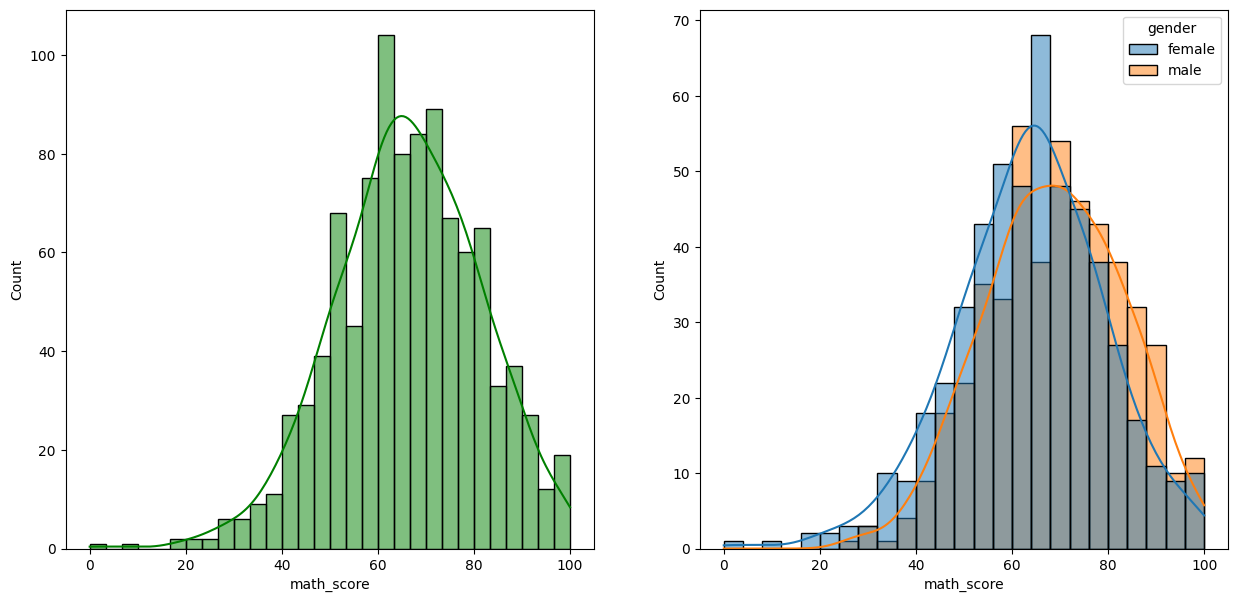

In [43]:
fig, axis = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df, x='math_score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x='math_score', hue='gender', kde=True)
plt.plot()

`Insights`: Female students tend to perform well than male students in Mathematics.

[]

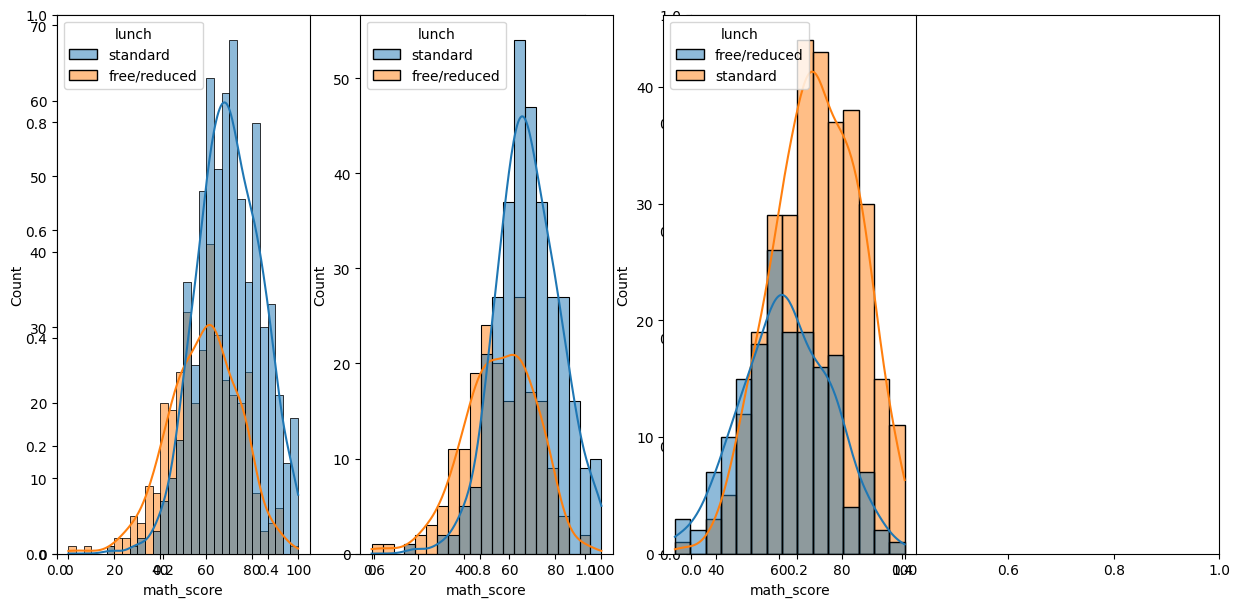

In [53]:
fig, axis = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(141)
sns.histplot(data=df, x='math_score', bins=30, kde=True, color='g', hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'], x='math_score', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'], x='math_score', kde=True, hue='lunch')
plt.plot()

`Insights`: Standard lunch helps perform well in exams.
            Standard lunch helps perform well in exams be it a male or a female.

#### 4.2 Checking for outliers

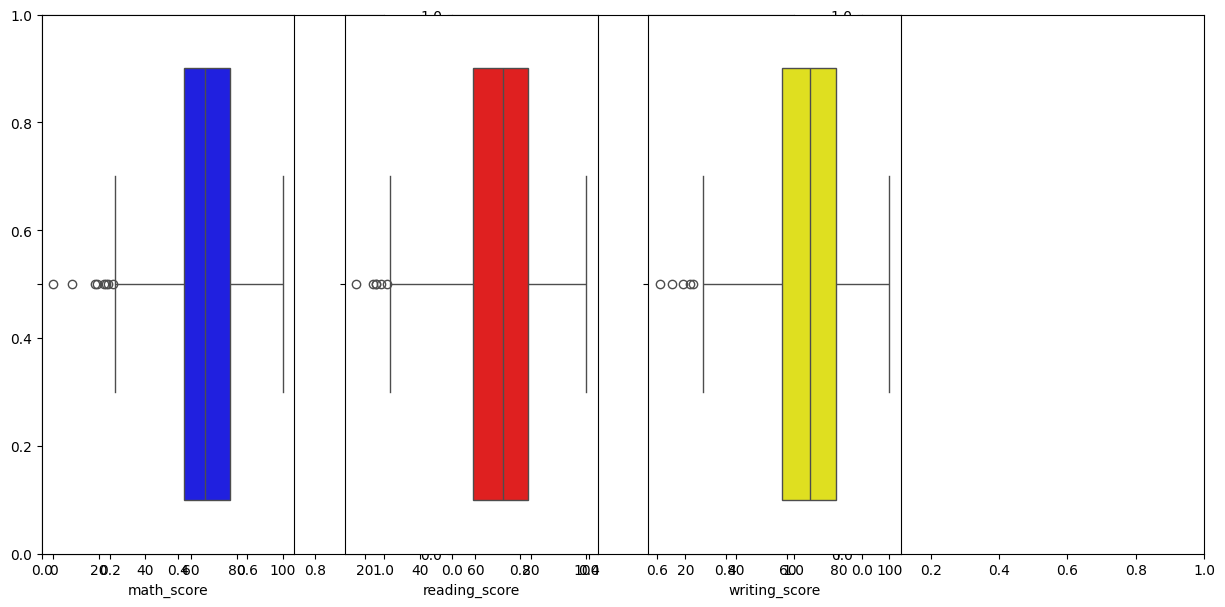

In [56]:
fig, axis = plt.subplots(1, 3, figsize=(15, 7))
plt.subplot(141)
sns.boxplot(data=df, x='math_score', color='blue')
plt.subplot(142)
sns.boxplot(data=df, x='reading_score', color='red')
plt.subplot(143)
sns.boxplot(data=df, x='writing_score', color='yellow')
plt.show()

`Insights`: As mentioned earlier, we have `outliers` for all these three numerical features but these
            outliers are important as the rest of the data.We can see from the boxplots that the 
            outliers for those students who scored marks between 0-20 but they are real. So we'll
            keep them.

### 5. Data Pre-processing

`Insights`: As mentioned earlier, we don't have any `missing values` nor do we have `duplicated` or `typos` 
            data. Therefore, the dataset is already `cleaned`.

### 6. Feature Engineering 

We will perform the FE in the model training part (`MODEL TRAINING.ipynb`) - like encoding, scaling, etc.


### 7. MODEL TRAINING

The model training will be performed in `MODEL TRAINING.ipynb` file.